In [14]:
#### Load library
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.image as mpimg
import matplotlib as mpl
from matplotlib.pyplot import rc_context
from gprofiler import GProfiler

import os

# Directory path

import SpatialproxseqClasses as SPC
import Proxseqnetwork as WPPI

#*****
mpl.rcdefaults()
# Set font to be arial
mpl.rc('font', **{'sans-serif':'Arial', 'size':12})
mpl.rcParams['mathtext.rm'] = 'sans' # to have non-italic greek letter, use r'$\mathrm{\alpha}$', does NOT work with f-string
mpl.rcParams['axes.titlesize'] = 12
# Set default tick size
mpl.rcParams['xtick.major.size'] = 5.5
mpl.rcParams['ytick.major.size'] = 5.5
mpl.rcParams['xtick.minor.size'] = 2.5
mpl.rcParams['ytick.minor.size'] = 2.5
# Default legend settings
mpl.rcParams['legend.fancybox'] = False
mpl.rcParams['legend.edgecolor'] = 'k'

#to store text as text, not as path
new_rc_params = {'text.usetex': False,
                 "svg.fonttype": 'none'}
mpl.rcParams.update(new_rc_params)

sc.settings.verbosity = 3


In [15]:
#read cell idents
a1_idents = pd.read_csv("A1_adata_mRNA_cell_clusters.csv", index_col=0)
a1_fisher = pd.read_csv('A1_fisher_test.csv', index_col=0)
a1_pla_weight = pd.read_csv('A1_weighted_sc_pla.csv', index_col=0)

In [16]:
selected_cells = a1_idents.index.tolist()
a1_fisher = a1_fisher[selected_cells]
a1_pla_weight = a1_pla_weight[selected_cells]


In [17]:
#read PLA data and transform the data
data = pd.read_csv('A1-PLA_count_matrix.txt.gz', sep="\t",index_col=0)
# Update row names (index)
data.index = data.index.str.replace(r"^VCAM1_B:(.*)$", r"CD40_A:\1", regex=True)
data.index = data.index.str.replace(r"^CD29_B:(.*)$", r"CD279_A:\1", regex=True)
data.index = data.index.str.replace(r"^LFA1_B:(.*)$", r"CD11a_A:\1", regex=True)
valid_condition = ~data.index.str.contains(r'((:.*_A)|(_B:))', regex=True)

# Apply the filter to the dataframe
pla = data[valid_condition]

#remover suffix 
pla.index = pla.index.str.replace(r'(_A|_B)', '', regex=True)
#exclude IgG
pla = pla.loc[~pla.index.str.contains('HLADPRQ'),:]
pla = pla[selected_cells]

pla_obj = SPC.sproxseqObject(pla)
pla_obj.compute_protein_pair_counts()
pla_obj.compute_protein_abundance()

/var/folders/zq/r1fxzh5j34100gjpvnw5chf40000gp/T/ipykernel_2223/1643838975.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  valid_condition = ~data.index.str.contains(r'((:.*_A)|(_B:))', regex=True)


In [18]:
my_order = ['CD19', 'CD20', 'CD21', 'CD23', 'CD24','CD27','CD35', 'CD38','IgD','IgM','HIgG','VCAM1','CD32',
           'CD3','CD4','CD8','CD279','CD28','CD40',
           'CD86','PDL2','CD147','CD81','CD9','ICAM1', 'CD29','ITGA4','LFA1','CD11a',
           'mIgG1', 'mIgG2a', 'mIgG2b']

In [19]:
#plot raw log10(umi+1) pla count
my_avg_count = pd.DataFrame({'mean':np.log10(pla_obj.pla_count+1).mean(axis=1)})
my_avg_count['probeA'] = [s.split(':')[0] for s in my_avg_count.index]
my_avg_count['probeB'] = [s.split(':')[1] for s in my_avg_count.index]
my_avg_count = my_avg_count.pivot(index='probeA', columns='probeB', values='mean')

In [20]:
my_avg_fisher = pd.DataFrame({'fisher':(a1_fisher<=0.05).sum(axis=1)/a1_fisher.shape[1]})
my_avg_fisher['probeA'] = [s.split(':')[0] for s in my_avg_fisher.index]
my_avg_fisher['probeB'] = [s.split(':')[1] for s in my_avg_fisher.index]
my_avg_fisher = my_avg_fisher.pivot(index='probeA', columns='probeB', values='fisher')

In [21]:
def make_upper_triangle_symmetric(df):
    # Ensure the DataFrame is square (same number of rows and columns)
    if df.shape[0] != df.shape[1]:
        raise ValueError("The DataFrame must be square to be made symmetric.")
    
    # Copy the upper triangle to the lower triangle
    upper_triangle = np.triu(df)  # Get the upper triangle values
    symmetric_df = pd.DataFrame(upper_triangle, index=df.index, columns=df.columns)

    # Fill the lower triangle by transposing the upper triangle
    symmetric_df = symmetric_df + symmetric_df.T - np.diag(np.diag(df))  # Subtract the diagonal to avoid doubling it

    return symmetric_df

In [22]:
my_avg_weight = pd.DataFrame({'mean':a1_pla_weight.mean(axis=1)})
my_avg_weight['probeA'] = [s.split(':')[0] for s in my_avg_weight.index]
my_avg_weight['probeB'] = [s.split(':')[1] for s in my_avg_weight.index]
my_avg_weight = my_avg_weight.pivot(index='probeA', columns='probeB', values='mean')
my_avg_weight = make_upper_triangle_symmetric(my_avg_weight)

In [23]:
# Align both DataFrames to their shared rows and columns
common_index = my_avg_fisher.index.intersection(my_avg_weight.index)
common_columns = my_avg_fisher.columns.intersection(my_avg_weight.columns)

# Subset to the common region
fisher_common = my_avg_fisher.loc[common_index, common_columns]
weight_common = my_avg_weight.loc[common_index, common_columns]

# Create the mask and apply it
mask = fisher_common <= 0.05
weight_common_masked = weight_common.mask(mask, 0)

# Replace the masked part back into original my_avg_weight (if desired)
my_avg_weight.update(weight_common_masked)

In [24]:
# Take the element-wise maximum of the matrix and its transpose
my_avg_weight_sym = my_avg_weight.combine(my_avg_weight.T, func=np.fmax)

In [25]:
# Function 1: Raw PLA Count
def generate_count_heatmap(pla_obj, my_order, region, ax):
    my_avg_count = pd.DataFrame({'mean': np.log10(pla_obj + 1).mean(axis=1)})
    my_avg_count['probeA'] = [s.split(':')[0] for s in my_avg_count.index]
    my_avg_count['probeB'] = [s.split(':')[1] for s in my_avg_count.index]
    my_avg_count = my_avg_count.pivot(index='probeA', columns='probeB', values='mean')

    sns.heatmap(
        my_avg_count.loc[my_order, my_order],
        ax=ax,
        linewidths=0.1,
        square=True,
        cmap=sns.cubehelix_palette(light=0.95, dark=0.15, as_cmap=True),
        vmin = 0,
        vmax = 2.5,
        cbar_kws={'label': "Average log10(UMI + 1)", 'shrink': 0.8, 'pad': 0.02}
    )

    ax.set_title(f"Raw PLA Count ({region})", fontsize=9)
    ax.set_xlabel("Probe B target", fontsize=8)
    ax.set_ylabel("Probe A target", fontsize=8)
    ax.set_xticks(range(len(my_order)))
    ax.set_xticklabels(my_order, rotation=90, ha='center', fontsize=8)
    ax.set_yticks(range(len(my_order)))
    ax.set_yticklabels(my_order, rotation=0, fontsize=8)

# Function 2: Fisher's Exact Test
def generate_fisher_heatmap(df, my_order, region, ax):
    my_avg_fisher = pd.DataFrame({'fisher': (df <= 0.05).sum(axis=1) / df.shape[1]})
    my_avg_fisher['probeA'] = [s.split(':')[0] for s in my_avg_fisher.index]
    my_avg_fisher['probeB'] = [s.split(':')[1] for s in my_avg_fisher.index]
    my_avg_fisher = my_avg_fisher.pivot(index='probeA', columns='probeB', values='fisher')

    sns.heatmap(
        my_avg_fisher.loc[my_order, my_order],
        ax=ax,
        linewidths=0.1,
        square=True,
        cmap='YlGnBu',
        vmin = 0,
        vmax = 0.8,
        cbar_kws={'label': "Ratio of Positive Spots", 'shrink': 0.8, 'pad': 0.02}
    )

    ax.set_title(f"Fisher's Exact Test ({region})", fontsize=9)
    ax.set_xlabel("Probe B target", fontsize=8)
    ax.set_ylabel("Probe A target", fontsize=8)
    ax.set_xticks(range(len(my_order)))
    ax.set_xticklabels(my_order, rotation=90, ha='center', fontsize=8)
    ax.set_yticks(range(len(my_order)))
    ax.set_yticklabels(my_order, rotation=0, fontsize=8)

# Function 3: Fractional Overlap
def generate_weight_heatmap(df1, df2, my_order, region, ax):
    my_avg_weight = pd.DataFrame({'mean': df1.mean(axis=1)})
    my_avg_weight['probeA'] = [s.split(':')[0] for s in my_avg_weight.index]
    my_avg_weight['probeB'] = [s.split(':')[1] for s in my_avg_weight.index]
    my_avg_weight = my_avg_weight.pivot(index='probeA', columns='probeB', values='mean')
    my_avg_weight = make_upper_triangle_symmetric(my_avg_weight)

    my_avg_fisher = pd.DataFrame({'fisher': (df2 <= 0.05).sum(axis=1) / df2.shape[1]})
    my_avg_fisher['probeA'] = [s.split(':')[0] for s in my_avg_fisher.index]
    my_avg_fisher['probeB'] = [s.split(':')[1] for s in my_avg_fisher.index]
    my_avg_fisher = my_avg_fisher.pivot(index='probeA', columns='probeB', values='fisher')

    # Mask based on Fisher
    common_index = my_avg_fisher.index.intersection(my_avg_weight.index)
    common_columns = my_avg_fisher.columns.intersection(my_avg_weight.columns)
    fisher_common = my_avg_fisher.loc[common_index, common_columns]
    weight_common = my_avg_weight.loc[common_index, common_columns]

    mask = fisher_common <= 0.15
    weight_common_masked = weight_common.mask(mask, 0)
    my_avg_weight.update(weight_common_masked)

    # Symmetrize
    my_avg_weight_sym = my_avg_weight.combine(my_avg_weight.T, func=np.fmax)

    # Plot
    sns.heatmap(
        my_avg_weight_sym.loc[my_order, my_order],
        ax=ax,
        linewidths=0.1,
        square=True,
        cmap='Reds',
         vmin = 0,
        vmax = 0.25,
        cbar_kws={'label': "Average Fractional Overlap", 'shrink': 0.8, 'pad': 0.02}
    )

    ax.set_title(f"Fractional Overlap ({region})", fontsize=9)
    ax.set_xlabel("Probe B target", fontsize=8)
    ax.set_ylabel("Probe A target", fontsize=8)
    ax.set_xticks(range(len(my_order)))
    ax.set_xticklabels(my_order, rotation=90, ha='center', fontsize=8)
    ax.set_yticks(range(len(my_order)))
    ax.set_yticklabels(my_order, rotation=0, fontsize=8)


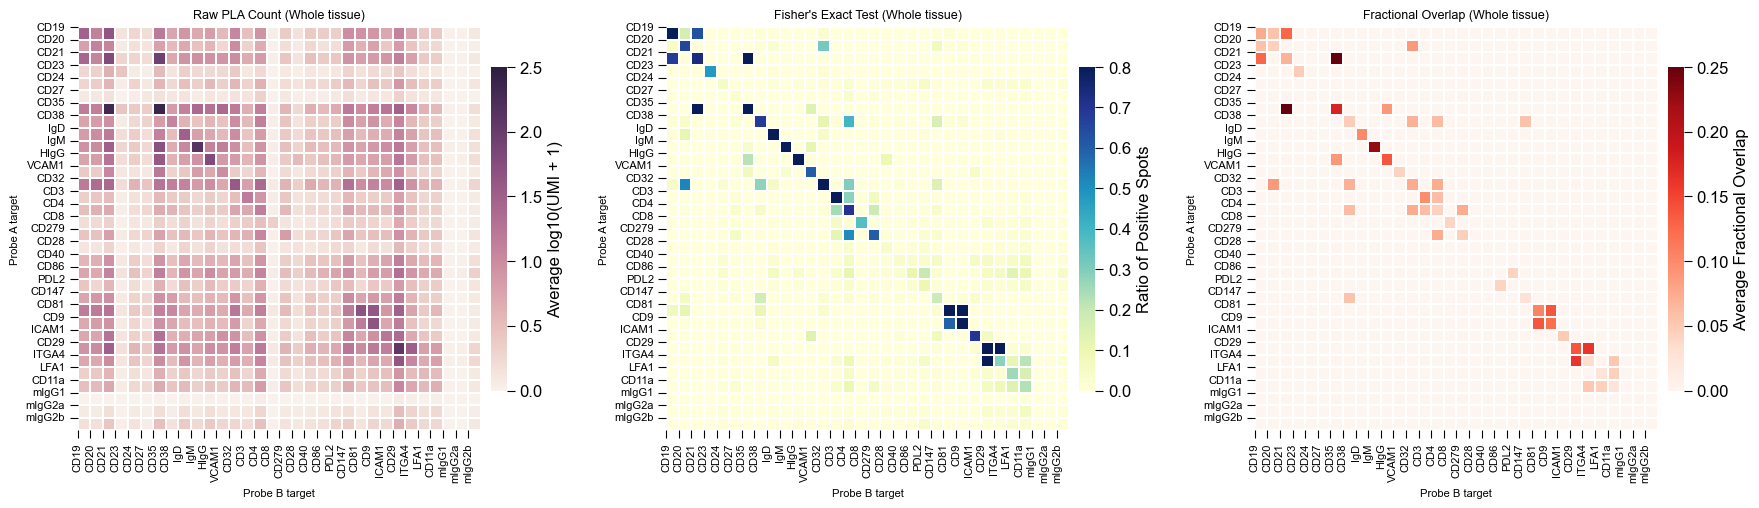

In [26]:
#heatmap based on cluster information, Germinal center

# Step 2: Subset columns of each matrix by these cell indices
a1_pla = pla_obj.pla_count

# Create one figure with 3 subplots horizontally
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot each heatmap in its respective subplot
generate_count_heatmap(a1_pla, my_order, 'Whole tissue', axes[0])
generate_fisher_heatmap(a1_fisher, my_order, 'Whole tissue', axes[1])
generate_weight_heatmap(a1_pla_weight, a1_fisher, my_order, 'Whole tissue', axes[2])

# Adjust layout
fig.tight_layout(pad=1.5)
# Optional: Save or show
fig.savefig("figures/A1_whole_tissue_heatmaps.png", format="png", dpi=300)
fig.savefig("figures/A1_whole_tissue_heatmaps.svg", format="svg", dpi=300)

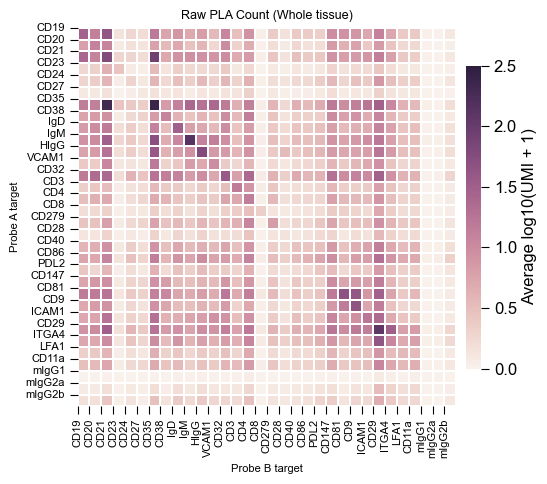

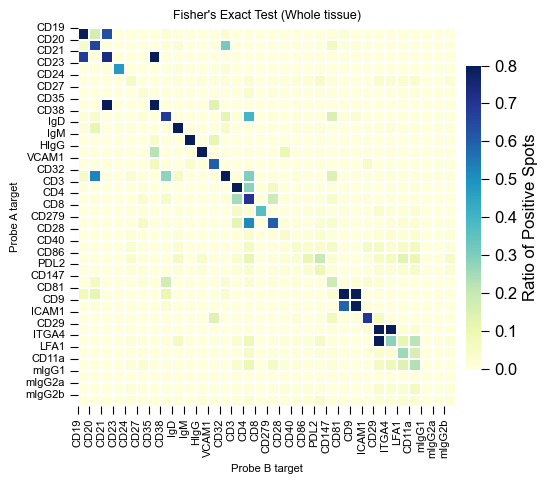

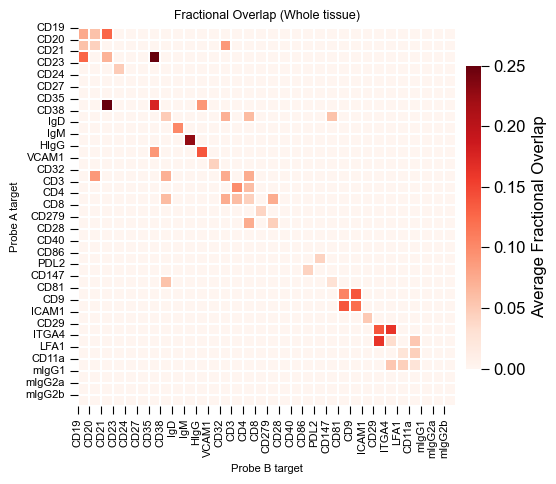

In [27]:
# Heatmap 1: Count heatmap
fig1, ax1 = plt.subplots(figsize=(6, 5))
generate_count_heatmap(a1_pla, my_order, 'Whole tissue', ax1)
fig1.tight_layout()
fig1.savefig("figures/Fig-3a.png", dpi=300)
fig1.savefig("figures/Fig-3a.svg", dpi=300)

# Heatmap 2: Fisher heatmap
fig2, ax2 = plt.subplots(figsize=(6, 5))
generate_fisher_heatmap(a1_fisher, my_order, 'Whole tissue', ax2)
fig2.tight_layout()
fig2.savefig("figures/Fig-3b.png", dpi=300)
fig2.savefig("figures/Fig-3b.svg", dpi=300)

# Heatmap 3: Weighted heatmap
fig3, ax3 = plt.subplots(figsize=(6, 5))
generate_weight_heatmap(a1_pla_weight, a1_fisher, my_order, 'Whole tissue', ax3)
fig3.tight_layout()
fig3.savefig("figures/Fig-3d.png", dpi=300)
fig3.savefig("figures/Fig-3d.svg", dpi=300)


In [28]:
a1_idents['mrna_annotation'].unique()

array(['Epithelial-crypt', 'T:B border', 'Light zone', 'T cell zone',
       'Non-GC follicles', 'Dark zone', 'Mantle zone',
       'Epithelial-basal cells'], dtype=object)

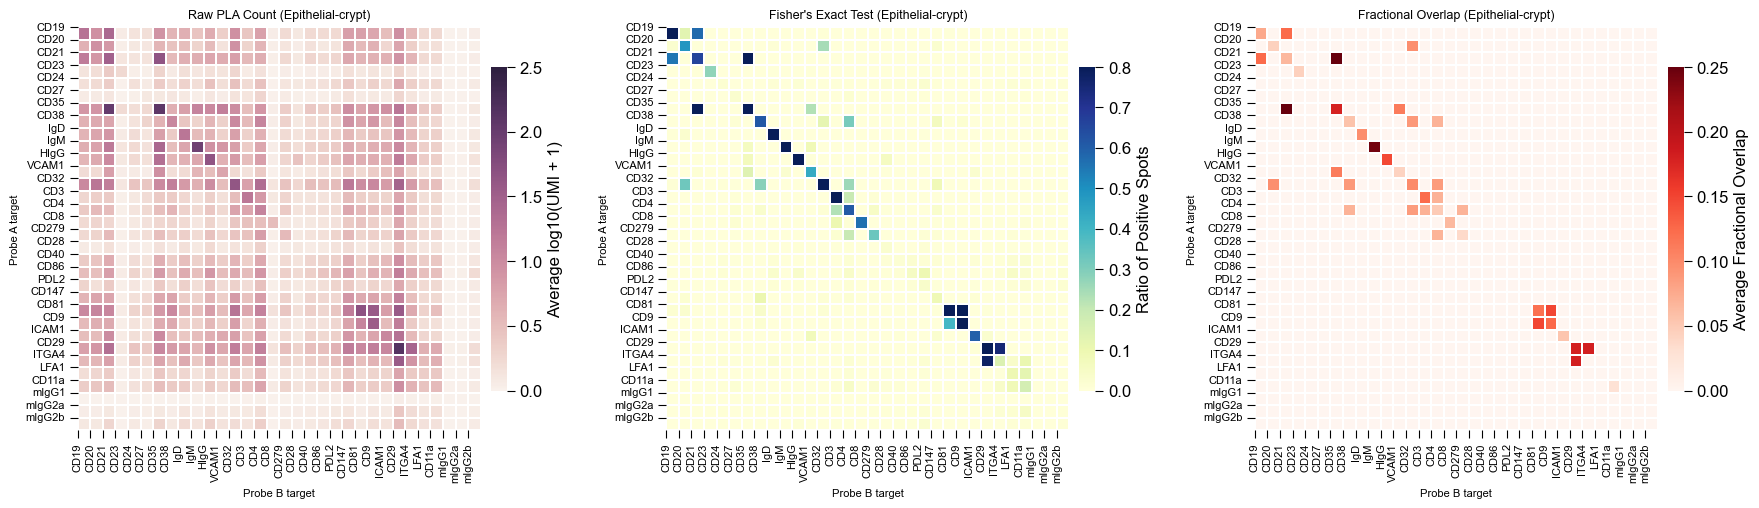

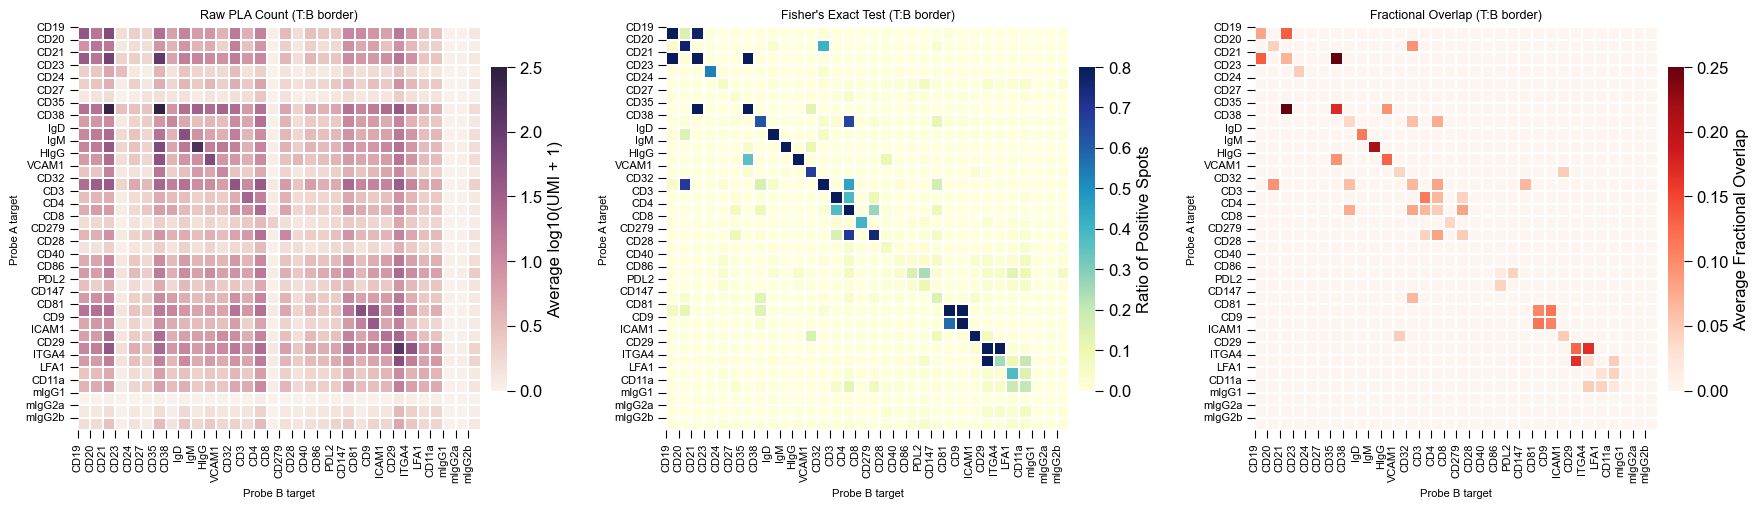

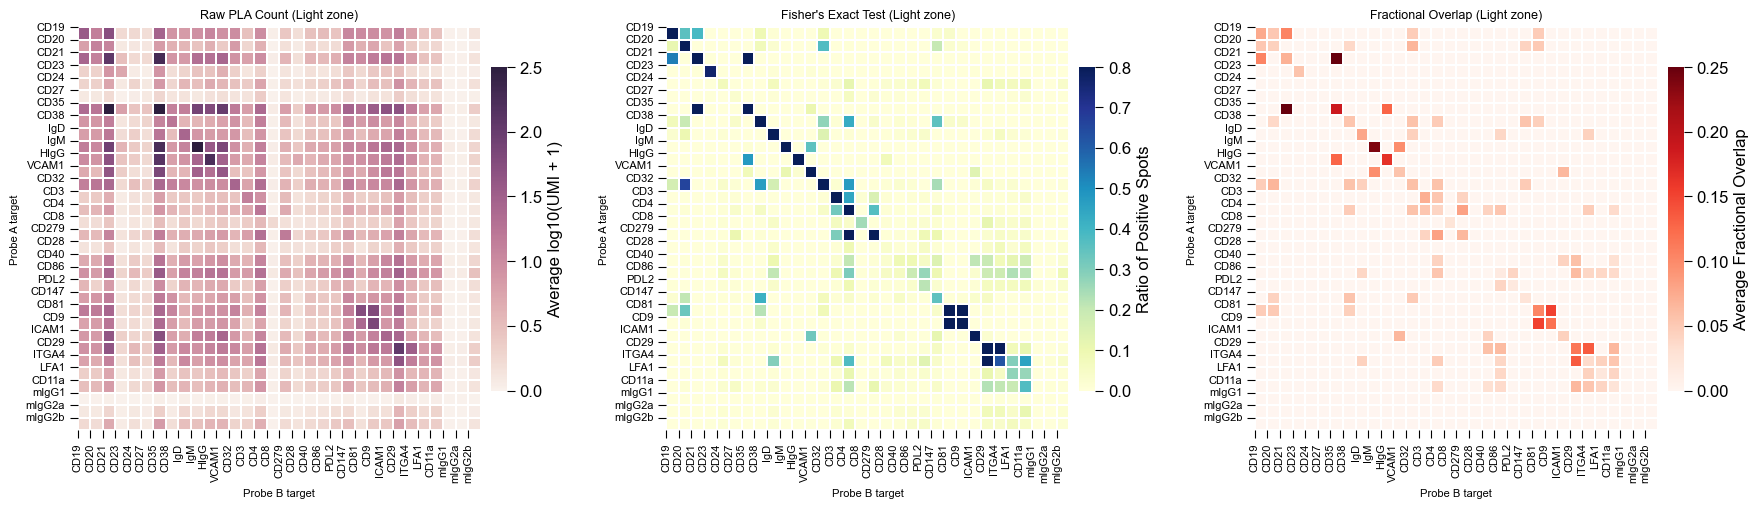

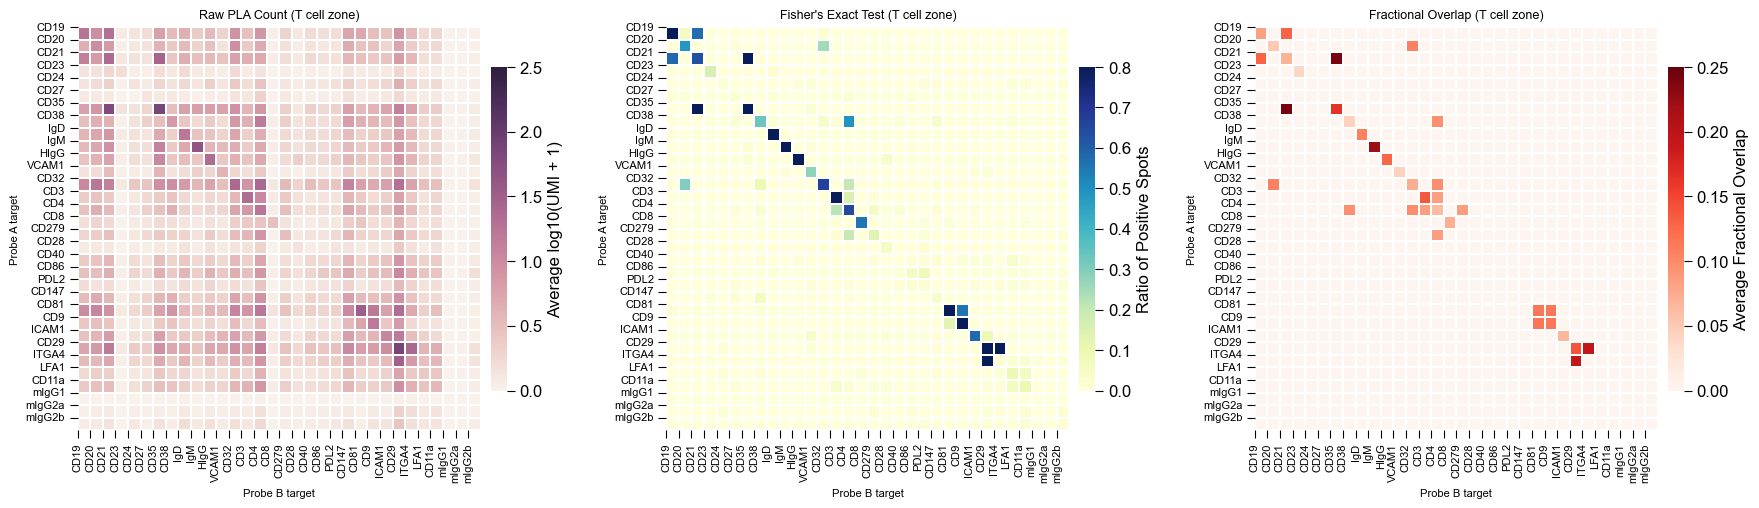

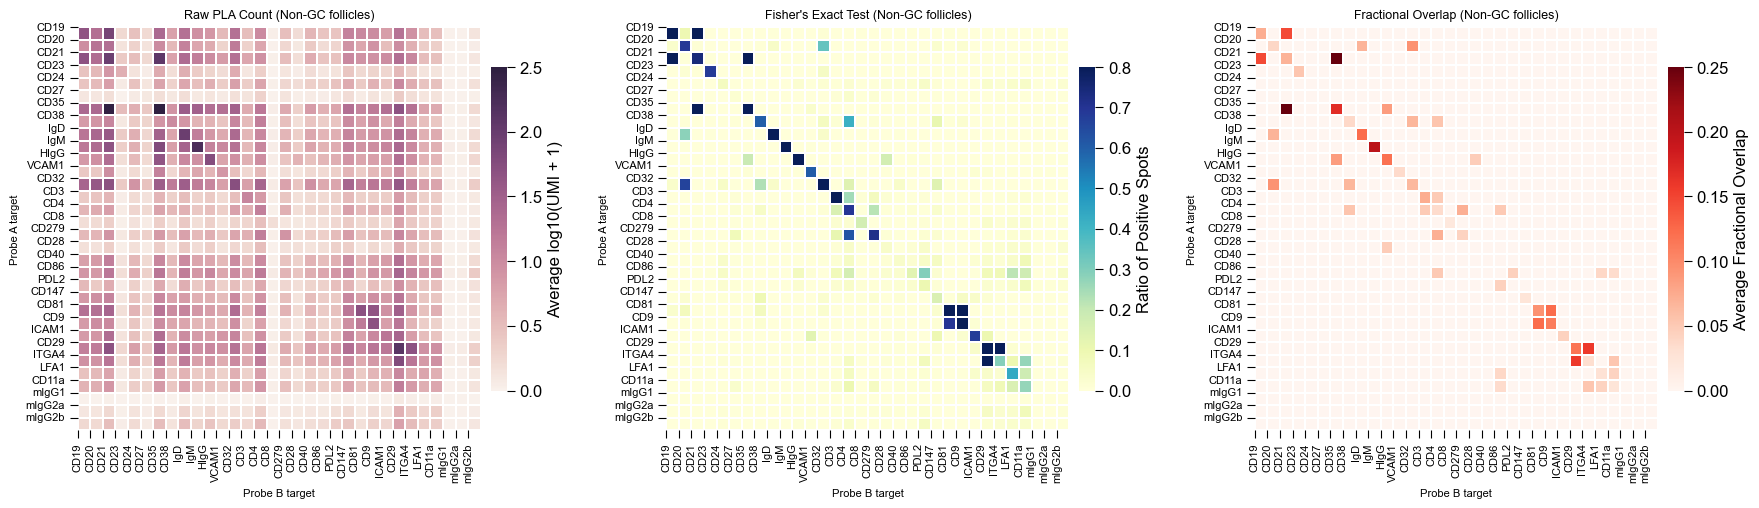

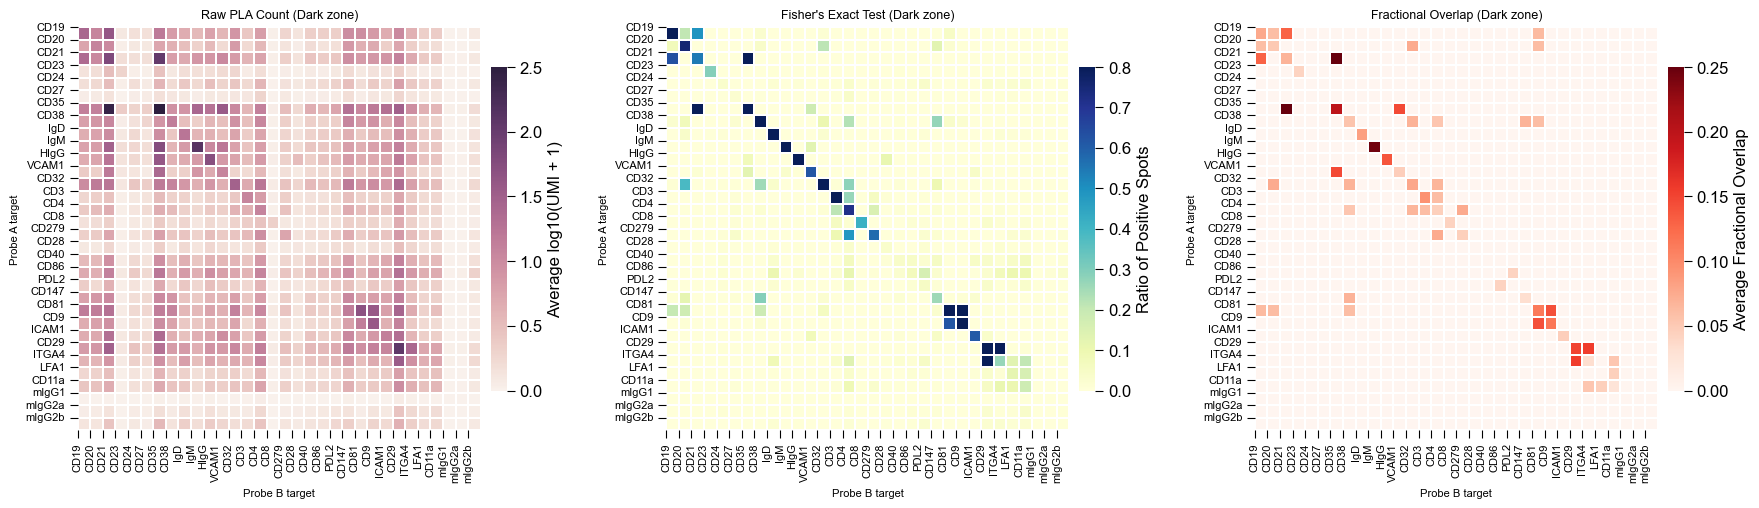

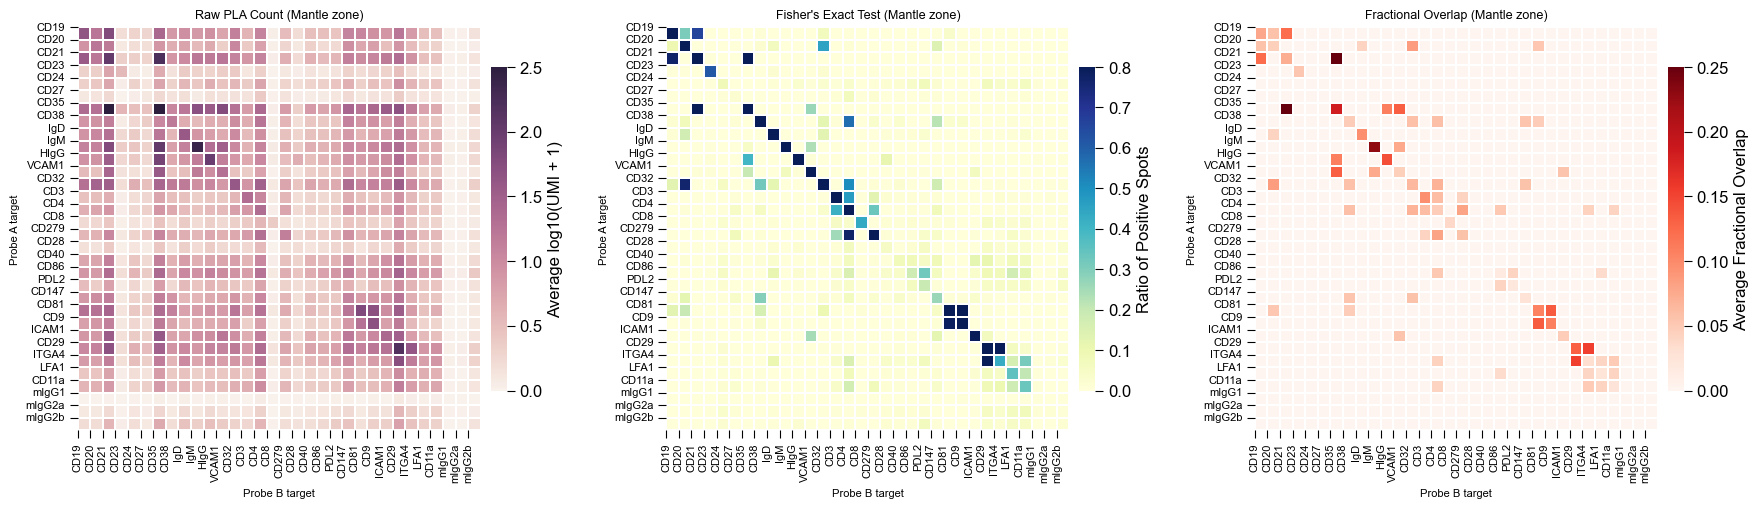

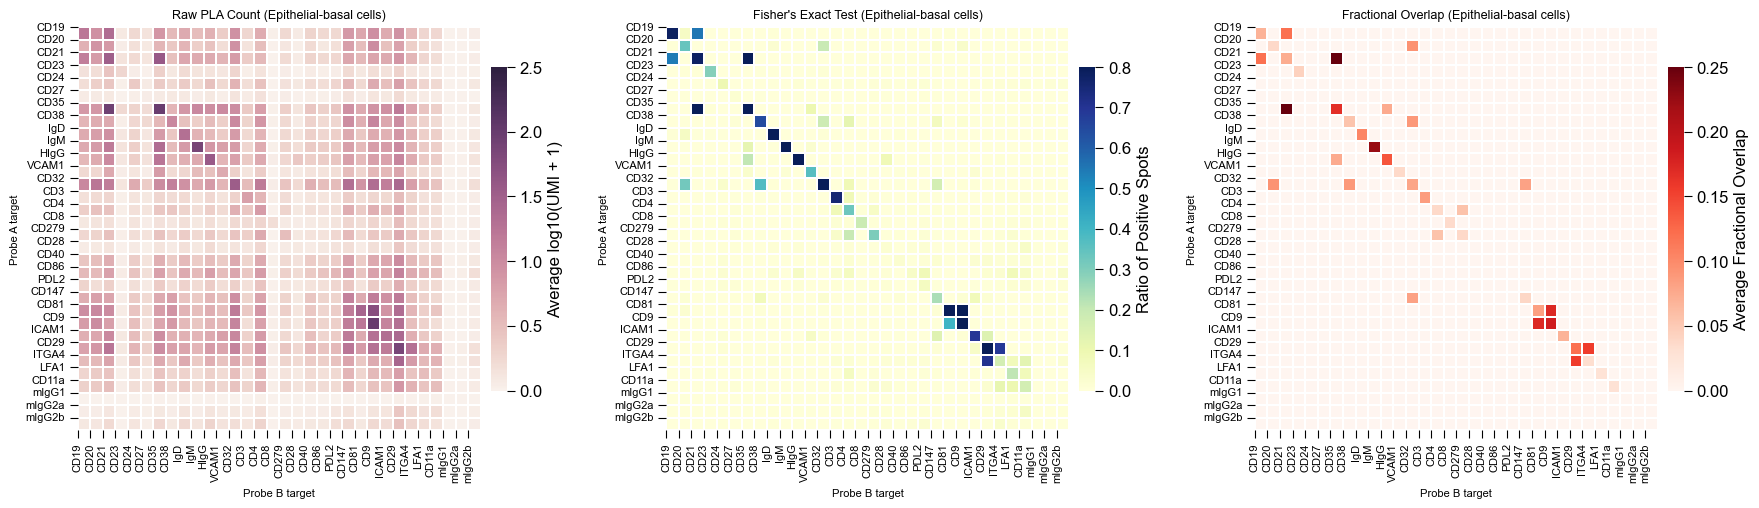

In [29]:
# Define all unique clusters to iterate through
cluster_list = a1_idents["mrna_annotation"].unique()

# Loop through each cluster
for cluster_name in cluster_list:
    # Step 1: Get cell indices
    cluster_cells = a1_idents[a1_idents['mrna_annotation'] == cluster_name].index

    # Step 2: Subset matrices
    pla_cluster = pla_obj.pla_count[cluster_cells]
    fisher_cluster = a1_fisher[cluster_cells]
    pla_weight_cluster = a1_pla_weight[cluster_cells]

    # Step 3: Plot into 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    generate_count_heatmap(pla_cluster, my_order, cluster_name, axes[0])
    generate_fisher_heatmap(fisher_cluster, my_order, cluster_name, axes[1])
    generate_weight_heatmap(pla_weight_cluster, fisher_cluster, my_order, cluster_name, axes[2])

    # Step 4: Save
    fig.tight_layout(pad=1.5)

    # Create valid filename (lowercase, replace spaces with underscores)
    safe_name = cluster_name.replace(" ", "_").replace("/", "_").lower()

    fig.savefig(f"figures/Fig3-A1_{safe_name}_heatmaps.svg", format="svg", dpi=300)
    fig.savefig(f"figures/Fig3-A1_{safe_name}_heatmaps.png", format="png", dpi=300)

    plt.show(fig)  # Free memory after saving


In [30]:
def plot_cluster_network_shell(
    fisher_df, weight_df, 
    cluster_name="Selected Cluster", 
    fisher_threshold=0.05, 
    fraction_cutoff=0.15,
    save_prefix="A1"
):
    import networkx as nx
    import matplotlib.pyplot as plt
    import os

    # Step 1: Identify significant pairs
    fisher_pass_fraction = (fisher_df <= fisher_threshold).sum(axis=1) / fisher_df.shape[1]
    sig_pairs = fisher_pass_fraction[fisher_pass_fraction > fraction_cutoff].index.tolist()

    edge_list = []
    weights = []
    for pair in sig_pairs:
        a, b = pair.split(":")
        ab = f"{a}:{b}"
        ba = f"{b}:{a}"

        if ab in weight_df.index:
            w = weight_df.loc[ab].mean()
        elif ba in weight_df.index:
            w = weight_df.loc[ba].mean()
        else:
            continue

        edge_list.append((a, b))
        weights.append(w)

    if not edge_list:
        print(f"No valid edges found for {cluster_name}.")
        return

    # Step 2: Build Graph
    G = nx.Graph()
    for (a, b), w in zip(edge_list, weights):
        G.add_edge(a, b, weight=w)

    # Step 3: Define shells
    outer_shell = ['CD19', 'CD20', 'CD21', 'CD23', 'CD24', 'CD35', 'CD38', 
                   'IgD', 'IgM', 'HIgG', 'VCAM1', 'CD32']
    inner_shell = ['CD3', 'CD4', 'CD8', 'CD279', 
                   'CD147', 'CD81', 'CD9',
                   'ICAM1', 'CD29', 'ITGA4', 'LFA1', 'CD11a', 
                   'CD28', 'CD40', 'CD86', 'PDL2']

    outer_shell = [p for p in outer_shell if p in G.nodes]
    inner_shell = [p for p in inner_shell if p in G.nodes]

    allowed_nodes = set(outer_shell + inner_shell)
    G.remove_nodes_from([n for n in G.nodes if n not in allowed_nodes])

    if not outer_shell or not inner_shell:
        pos = nx.spring_layout(G, seed=42)
    else:
        pos = nx.shell_layout(G, nlist=[outer_shell, inner_shell])

    # Step 4: Assign node colors
    tetraspanins = {'CD147', 'CD81', 'CD9'}
    integrins = {'ICAM1', 'CD29', 'ITGA4', 'LFA1', 'CD11a'}
    co_stimulatory = {'CD28', 'CD40', 'CD86', 'PDL2'}
    t_cell_markers = {'CD3', 'CD4', 'CD8', 'CD279'}
    b_cell_markers = set(outer_shell)

    node_colors = []
    for node in G.nodes:
        if node in tetraspanins:
            node_colors.append("mediumpurple")
        elif node in integrins:
            node_colors.append("mediumseagreen")
        elif node in co_stimulatory:
            node_colors.append("orange")
        elif node in t_cell_markers:
            node_colors.append("cornflowerblue")
        elif node in b_cell_markers:
            node_colors.append("gold")
        else:
            node_colors.append("lightgray")

    # Step 5: Draw
    plt.figure(figsize=(3.5, 3.5))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=9)

    edges = G.edges(data=True)
    edge_colors = []
    edge_widths = []
    for u, v, d in edges:
        edge_colors.append('black' if u != v else 'dimgray')
        edge_widths.append(d['weight'] * 20)

    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors)

    plt.axis('off')
    plt.title(cluster_name, fontsize=14)
    plt.tight_layout()

    os.makedirs("Figures", exist_ok=True)
    safe_name = cluster_name.replace(" ", "_").replace("/", "_").lower()

    plt.savefig(f"Figures/{save_prefix}_{safe_name}_network.png", dpi=300, facecolor='white')
    plt.savefig(f"Figures/{save_prefix}_{safe_name}_network.svg", dpi=300, facecolor='white')
    plt.show()




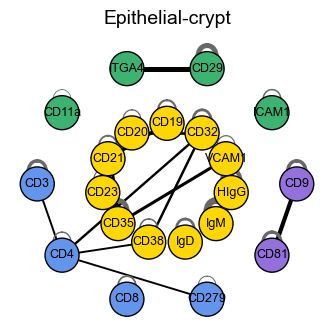

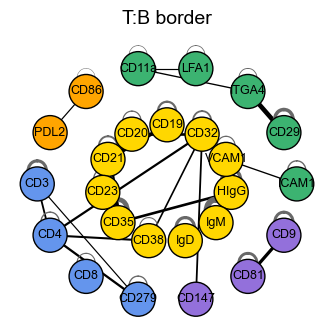

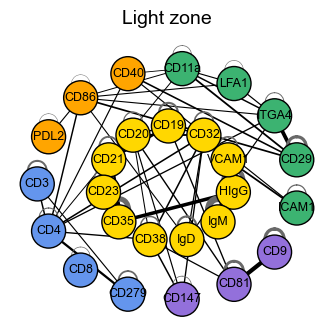

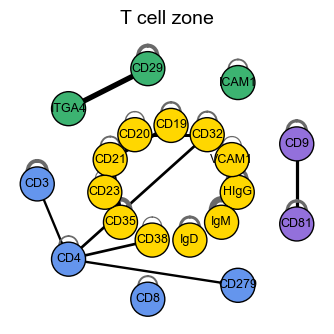

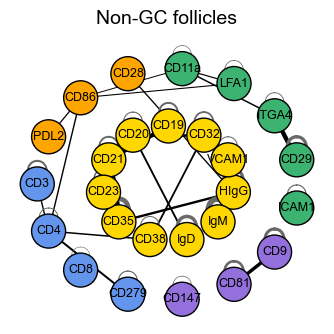

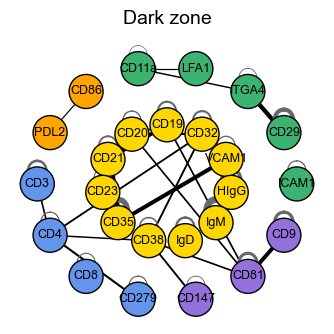

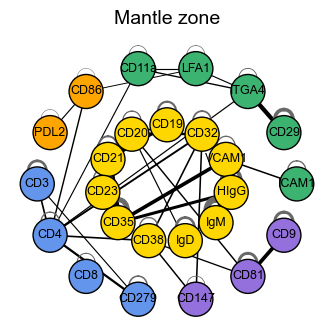

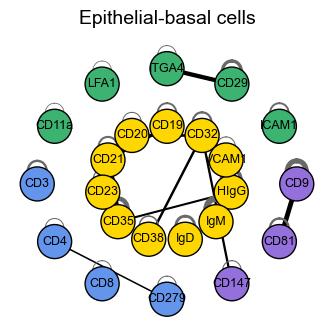

In [31]:
# ✅ Run for all clusters in a1_idents['mrna_annotation']
for cluster in a1_idents["mrna_annotation"].unique():
    selected_cells = a1_idents[a1_idents["mrna_annotation"] == cluster].index

    fisher_sub = a1_fisher[selected_cells]
    weight_sub = a1_pla_weight[selected_cells]

    plot_cluster_network_shell(
        fisher_df=fisher_sub,
        weight_df=weight_sub,
        cluster_name=cluster,
        save_prefix="Fig3e-A1"
    )
